# Midi Analysis

In [63]:
from pathlib import Path
from pretty_midi import PrettyMIDI

import pandas as pd
import matplotlib.pyplot as plt
import IPython
import seaborn as sns

## Load Data

In [64]:
# Paths
data_path = Path.cwd().parent / 'Data'
dl_mb = data_path / 'drumlearning' / 'drumlearning_basti'
dl_f = data_path / 'drumlearning' / 'drumlearning_foundational'
groove = data_path / 'e-gmd-v1.0.0'

In [65]:
# print paths
print(dl_mb)
print(dl_f)
print(groove)

C:\Users\minem\PycharmProjects\ITS-M\Master\GroovePal\Data\drumlearning\drumlearning_basti
C:\Users\minem\PycharmProjects\ITS-M\Master\GroovePal\Data\drumlearning\drumlearning_foundational
C:\Users\minem\PycharmProjects\ITS-M\Master\GroovePal\Data\e-gmd-v1.0.0


In [66]:
meta_dl_mb = dl_mb / 'info.txt'
meta_dl_f = dl_f / 'info.txt'

meta_mb = pd.read_csv(meta_dl_mb, sep='\t', header=None, names=['file', 'name', 'bpm', 'type'], index_col=0)
meta_f = pd.read_csv(meta_dl_f, sep='\t', header=None, names=['file', 'style', 'bpm', 'type'], index_col=0)

In [67]:
# cleaning
meta_mb['bpm'] = meta_mb['bpm'].apply(lambda x: int(x.split(' ')[0]))
meta_mb['bpm'] = meta_mb['bpm'].astype(int)

meta_f['bpm'] = meta_f['bpm'].apply(lambda x: int(x.split(' ')[0]))
meta_f['bpm'] = meta_f['bpm'].astype(int)

In [68]:
meta_mb.head()

,file,name,bpm,type
0,1_1.mid,Bark_1A,120,Pickup
1,1_2.mid,Bark_1A,120,CountIn
2,1_3.mid,Bark_1A,120,IntroPlay | Verse | Chorus
3,1_4.mid,Bark_1A,120,Verse | Bridge
4,1_5.mid,Bark_1A,120,IntroPlay | Verse | Chorus


In [69]:
meta_f.head()

,file,style,bpm,type
0,Variation_01.mid,METALHEADS,98,FULL_SONG
1,Variation_01.mid,METALHEADS,98,THEME
2,Variation_02.mid,METALHEADS,98,THEME
3,Variation_03.mid,METALHEADS,98,THEME
4,Variation_04.mid,METALHEADS,98,THEME


## Meta Analysis

### BPM Distribution

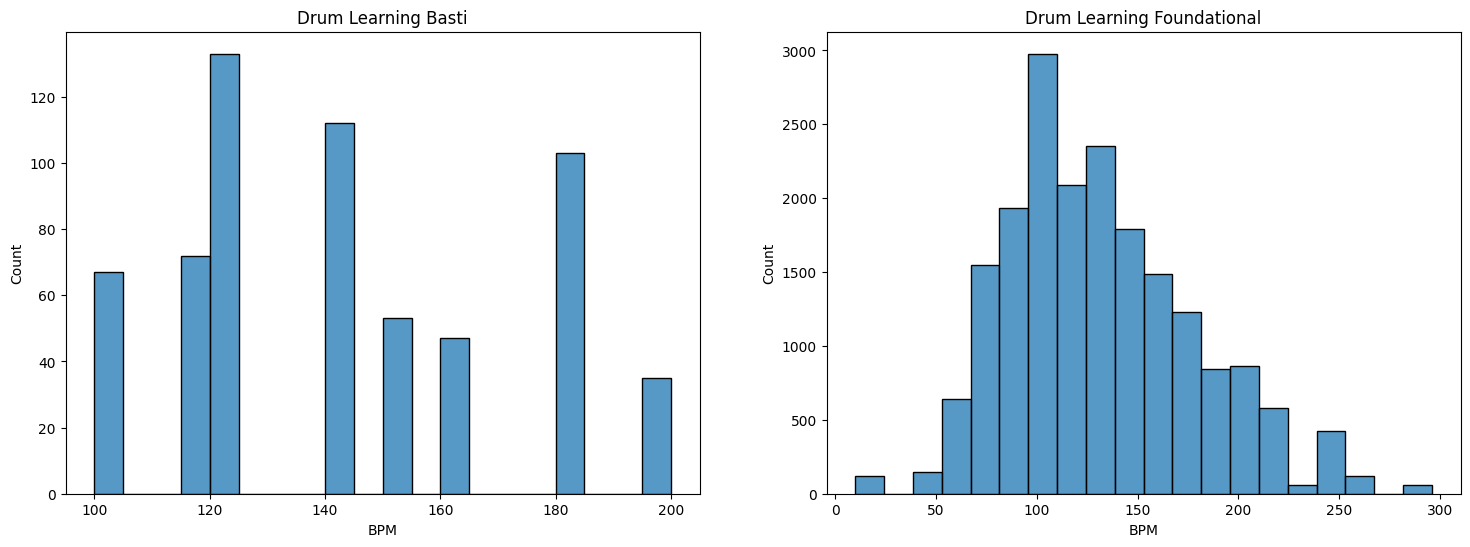

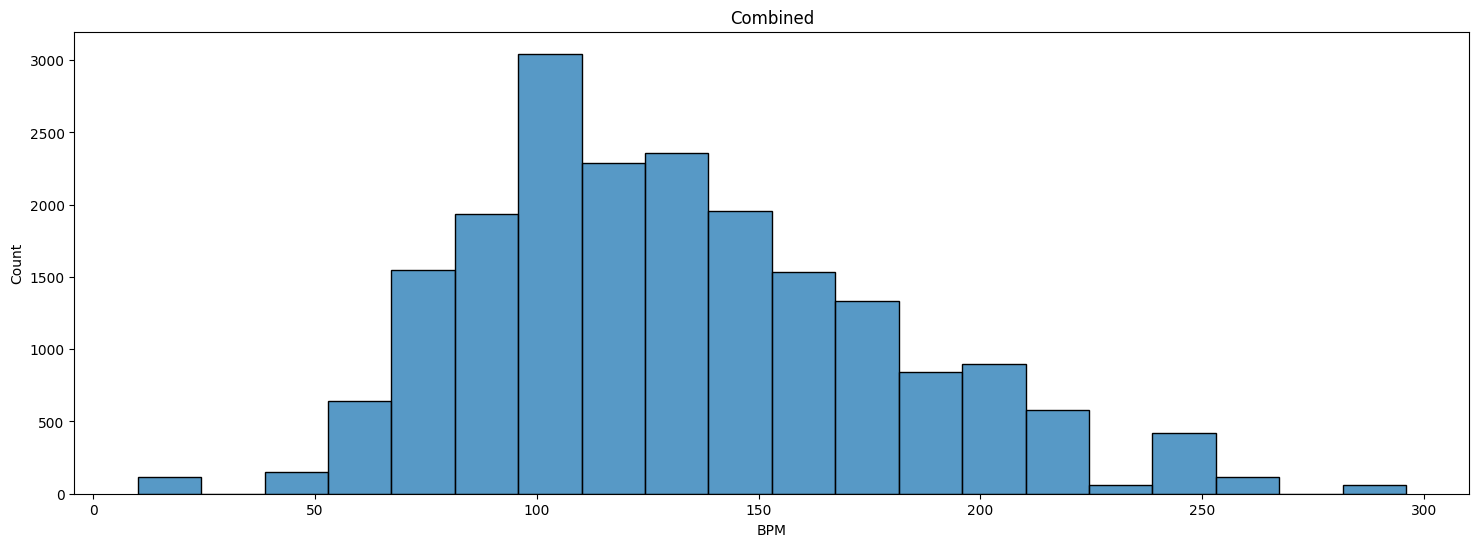

In [86]:
# Plot the distribution of BPMs in each dataset and together
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(meta_mb['bpm'], bins=20, ax=ax[0])
ax[0].set_title('Drum Learning Basti')
ax[0].set_xlabel('BPM')
ax[0].set_ylabel('Count')

sns.histplot(meta_f['bpm'], bins=20, ax=ax[1])
ax[1].set_title('Drum Learning Foundational')
ax[1].set_xlabel('BPM')
ax[1].set_ylabel('Count')

plt.show()

combined = pd.concat([meta_mb['bpm'], meta_f['bpm']])

fig, ax = plt.subplots(1, 1, figsize=(18, 6))
sns.histplot(combined, bins=20, ax=ax)
ax.set_title('Combined')
ax.set_xlabel('BPM')
ax.set_ylabel('Count')


plt.show()

### Style Distribution

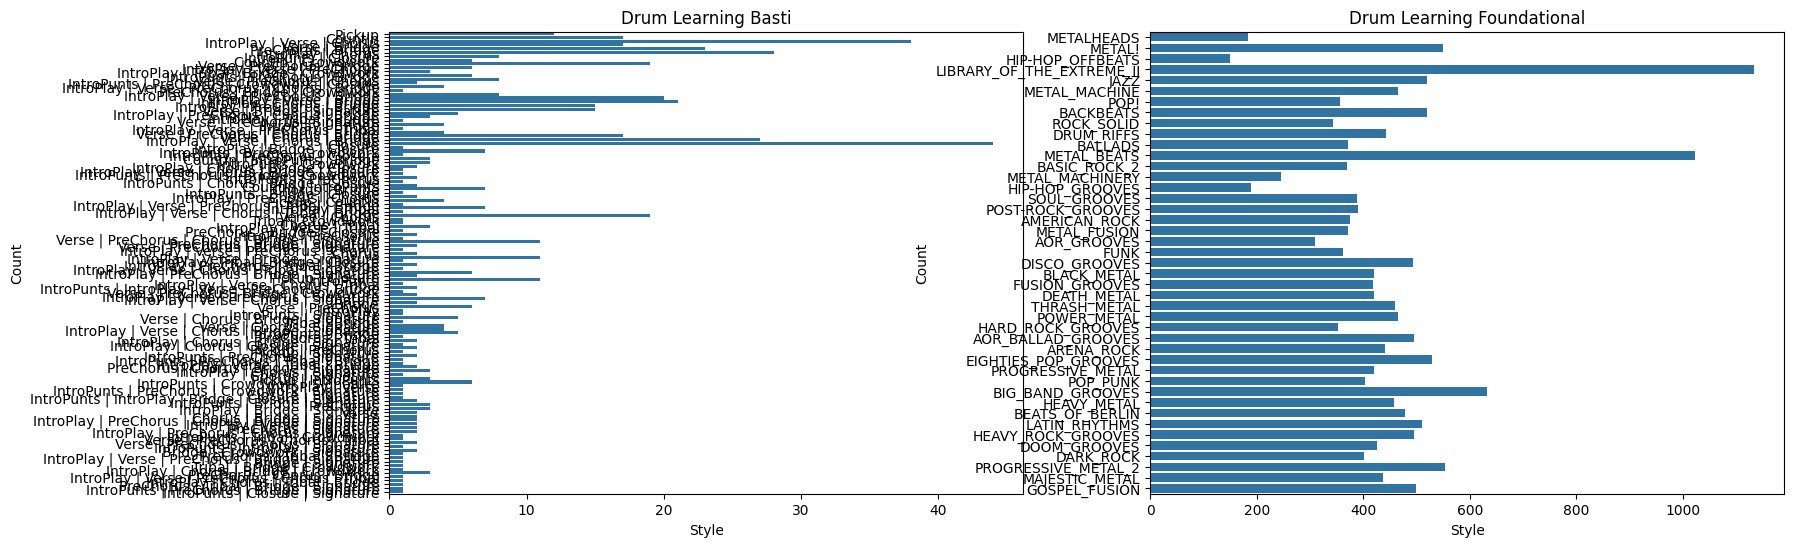

In [71]:
# Plot the distribution of styles in foundational

#-> foundational

### Type Distribution

In [ ]:
# Plot the distribution of types in basti


## Midi Analysis

- deviation from quantization (microtimings)
- tempo changes
- instrument distribution
- plot drum rolls with zoom function
- how many notes in total / average per file / per instrument -> distribution
- time signatures
- similar instruments -> group them
- patterns in sequences

In [72]:
# open 1 midi file
midi = PrettyMIDI(str(dl_mb / '1_1.mid'))

In [73]:
# get instruments
instruments = midi.instruments
instruments

[Instrument(program=0, is_drum=True, name="1_1")]

In [74]:
# get notes
notes = midi.instruments[0].notes
notes

[Note(start=2.739583, end=2.781250, pitch=84, velocity=69),
 Note(start=2.800000, end=2.841667, pitch=84, velocity=62),
 Note(start=2.863542, end=2.905208, pitch=84, velocity=51),
 Note(start=2.934375, end=2.976042, pitch=84, velocity=58),
 Note(start=3.008333, end=3.050000, pitch=84, velocity=91),
 Note(start=3.133333, end=3.175000, pitch=84, velocity=41),
 Note(start=3.257292, end=3.298958, pitch=84, velocity=82),
 Note(start=3.373958, end=3.415625, pitch=87, velocity=95),
 Note(start=3.496875, end=3.538542, pitch=46, velocity=98)]

In [75]:
# get tempo changes
tempo = midi.get_tempo_changes()
tempo

(array([0.]), array([120.]))

In [76]:
# get time signature changes
time_signature = midi.time_signature_changes
time_signature

[TimeSignature(numerator=4, denominator=4, time=0.0)]

In [77]:
# get key signature changes
key_signature = midi.key_signature_changes
key_signature

[]

## Groove Dataset

## Additional Datasets